# Continuous Distributions

## Uniform Distribution

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns 

from scipy.stats import uniform

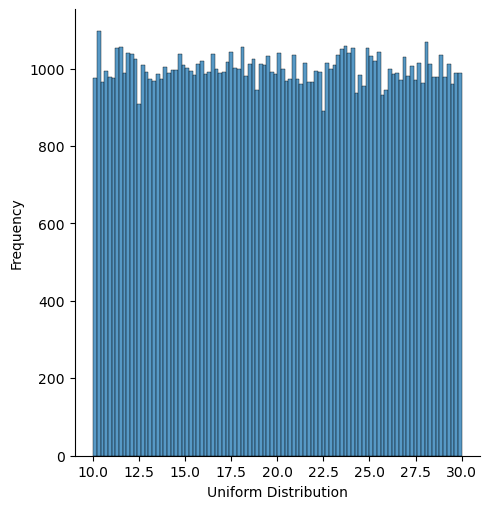

In [5]:
n = 10000
n *= 10

start = 10
width = 20

data_uniform = uniform.rvs(size=n, loc=start, scale=width)

ax = sns.displot(data_uniform,
                bins=100,
                kde=False
                )
ax.set(xlabel="Uniform Distribution", ylabel="Frequency")

# Normal distribution / Gaussian distribution

In [6]:
from scipy.stats import norm

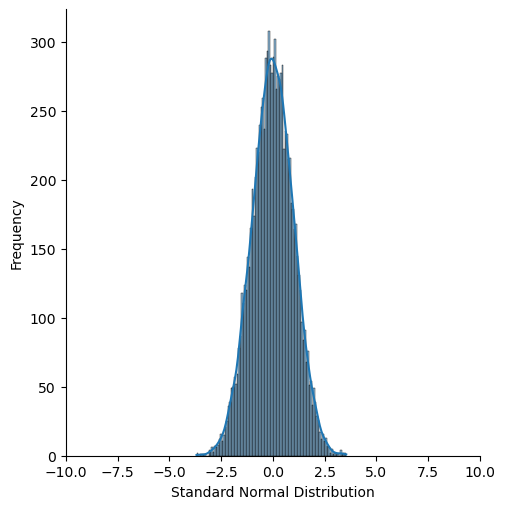

In [7]:
data_normal = norm.rvs(size=10000, loc=0, scale=1)

ax = sns.displot(data_normal,
                bins=100,
                kde=True
                )

plt.xlim(-10, 10)
_ = ax.set(xlabel="Standard Normal Distribution", ylabel="Frequency")

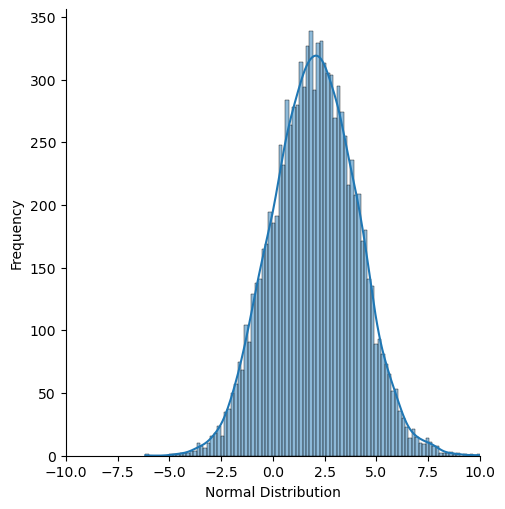

In [8]:
data_normal = norm.rvs(size=10000, loc=2, scale=2)

ax = sns.displot(data_normal, 
                bins=100,
                kde=True
                )

plt.xlim(-10, 10)
ax.set(xlabel="Normal Distribution", ylabel="Frequency")

# Exponential Distribution

In [9]:
from scipy.stats import expon

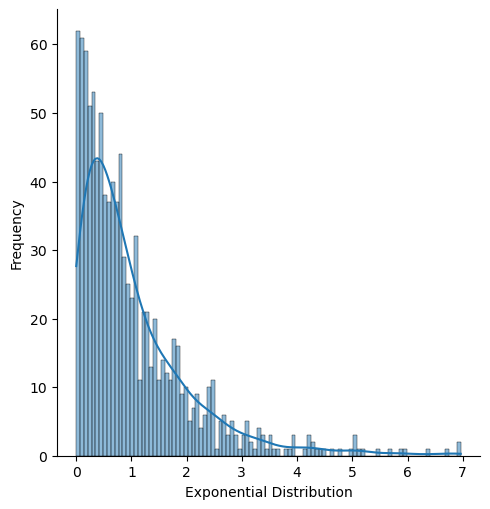

In [10]:
data_expon = expon.rvs(size=1000, loc=0, scale=1)

ax = sns.displot(data_expon,
                bins=100,
                kde=True
                )

# plt.xlim(-10, 10)
ax.set(xlabel="Exponential Distribution", ylabel="Frequency")

# Beta Distribution

In [11]:
# Beta and Gemma distributions are most often used, mostly in popluar models. See them yourself

In [12]:
from scipy.stats import beta

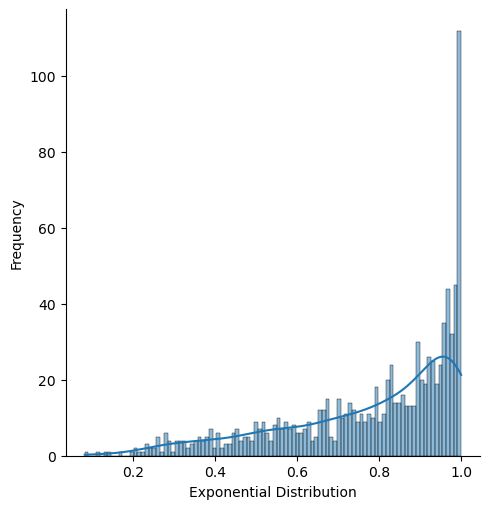

In [13]:
data_beta = beta.rvs(size=1000, a=2.31, b=0.627)

ax = sns.displot(data_beta, 
                bins=100,
                kde=True
                )
# plt.xlim(-10, 10)
_ = ax.set(xlabel="Exponential Distribution", ylabel="Frequency")

In [14]:
# Slightly advanced but very goood article on Beta disribution: 
# https://towardsdatascience.com/beta-distribution-intuition-examples-and-derivation-cf00f4db57af 

# Bayesian Inference and Continuous Distributions

## Sleep Data Analysis

In [15]:
# Case study source: https://github.com/WillKoehrsen/ai-projects/blob/master/bayesian_inference/bayes_rule_applied.ipynb 

import numpy as np
import pandas as pd
from IPython.core.pylabtools import figsize
import datetime

figsize(16, 6)

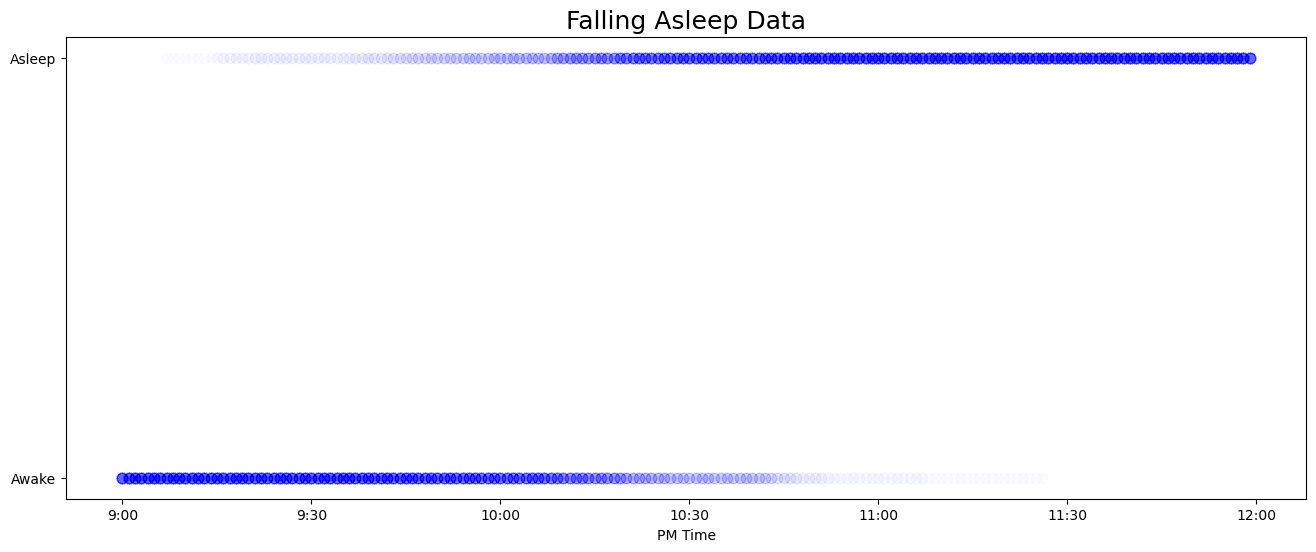

In [16]:
# Data formatted in different notebook
sleep_data = pd.read_csv('data/sleep_data.csv')

# Labels for plotting
sleep_labels = ['9:00', '9:30', '10:00', '10:30', '11:00', '11:30', '12:00']

# Sleep data
plt.scatter(sleep_data['time_offset'], sleep_data['indicator'], 
            s= 60, alpha=0.01, facecolor = 'b', edgecolors='b')
plt.yticks([0, 1], ['Awake', 'Asleep']); plt.xlabel('PM Time'); 
plt.title('Falling Asleep Data', size = 18)
plt.xticks([-60, -30, 0, 30, 60, 90, 120], sleep_labels);

In [17]:
sleep_data.head()

,Unnamed: 0,indicator,time_offset
0,2017-12-01 21:00:00,0,-60
1,2017-12-01 21:01:00,0,-59
2,2017-12-01 21:02:00,0,-58
3,2017-12-01 21:03:00,0,-57
4,2017-12-01 21:04:00,0,-56


In [18]:
# Sort the values by time offset
sleep_data.sort_values('time_offset', inplace=True)

# Time is the time offset
time = np.array(sleep_data.loc[:, 'time_offset'])

# Observations are the indicator
sleep_obs = np.array(sleep_data.loc[:, 'indicator'])

In [19]:
sleep_data.head()

,Unnamed: 0,indicator,time_offset
0,2017-12-01 21:00:00,0,-60
1620,2017-12-10 21:00:00,0,-60
7740,2018-01-13 21:00:00,0,-60
1980,2017-12-12 21:00:00,0,-60
4140,2017-12-24 21:00:00,0,-60


In [20]:
sleep_data.tail()

,Unnamed: 0,indicator,time_offset
8639,2018-01-17 23:59:00,1,119
1799,2017-12-10 23:59:00,1,119
10799,2018-01-29 23:59:00,1,119
11339,2018-02-01 23:59:00,1,119
8459,2018-01-16 23:59:00,1,119


In [21]:
time

array([-60, -60, -60, ..., 119, 119, 119], shape=(11340,))

In [22]:
sleep_obs

array([0, 0, 0, ..., 1, 1, 1], shape=(11340,))

In [23]:
sleep_data.loc[sleep_data['time_offset'] == 0]

,Unnamed: 0,indicator,time_offset
6540,2018-01-06 22:00:00,0,0
4380,2017-12-25 22:00:00,0,0
3660,2017-12-21 22:00:00,0,0
9240,2018-01-21 22:00:00,0,0
9600,2018-01-23 22:00:00,0,0
...,...,...,...
10320,2018-01-27 22:00:00,0,0
1140,2017-12-07 22:00:00,0,0
8880,2018-01-19 22:00:00,0,0
7080,2018-01-09 22:00:00,0,0


## Calculate probability at a particular time

In [24]:
time_offset = 15

In [25]:
awake_vals = sleep_data.loc[(sleep_data['time_offset'] == time_offset) 
                            & (sleep_data['indicator'] == 0)]

In [26]:
sleep_vals = sleep_data.loc[(sleep_data['time_offset'] == time_offset) 
                            & (sleep_data['indicator'] == 1)]

In [27]:
print(len(sleep_vals), len(awake_vals))

31 32


In [28]:
p_sleep_at_offset = len(sleep_vals) / (len(sleep_vals) + len(awake_vals))
print(p_sleep_at_offset)

0.49206349206349204


## Calculating the prior

In [29]:
# Logistic Parameters from Markov Chain Monte Carlo Notebook - Don't have to understand how got this, for now
alpha = 0.977400
beta = -0.067270

def calculate_prior(time, alpha, beta):
    p = 1.0 / (1.0 + np.exp(np.dot(beta, time) + alpha))
    return p

# Done using some other method here but in essence, it's the same as above. This other method works even if you have little data. 
time_est = np.linspace(time.min()- 5, time.max() + 5, 1000)[:, None]

# Probability at each time using mean values of alpha and beta
sleep_est = calculate_prior(time_est, alpha, beta)

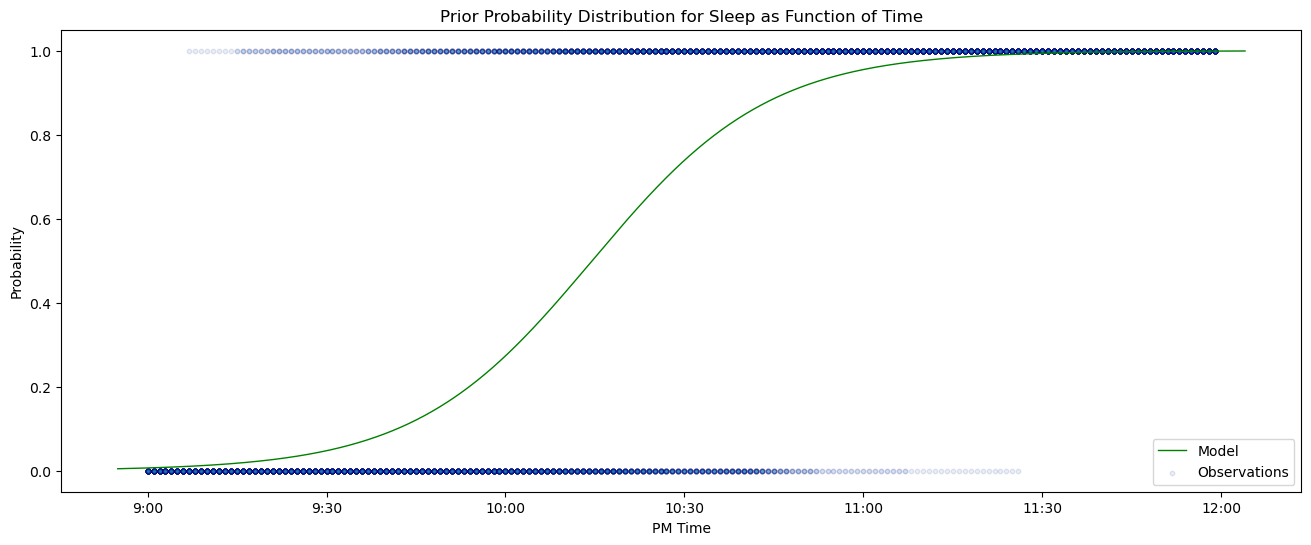

In [30]:
plt.plot(time_est, sleep_est, color = 'green', 
         lw=1, label="Model")
plt.scatter(time, sleep_obs, edgecolor = 'navy',
            s=10, alpha=0.1, label='Observations')
plt.title('Prior Probability Distribution for Sleep as Function of Time');
plt.legend()
plt.ylabel('Probability')
plt.xlabel('PM Time');
plt.xticks([-60, -30, 0, 30, 60, 90, 120], sleep_labels);

In [31]:
# Mini quiz: What type of distribution is this? 

In [32]:
print('The probability of sleep increases to above 50% at 10:{} PM.\n'.format(
          int(time_est[np.where(sleep_est > 0.5)[0][0]][0])
        )
     )

print('9:30  PM probability of being asleep: {:.2f}%.'.
      format(100 * calculate_prior(-30, alpha, beta)))
print('10:00 PM probability of being asleep: {:.2f}%.'.
      format(100 * calculate_prior(0, alpha, beta)))
print('10:30 PM probability of being asleep: {:.2f}%.'.
      format(100 * calculate_prior(15, alpha, beta)))

The probability of sleep increases to above 50% at 10:14 PM.

9:30  PM probability of being asleep: 4.76%.
10:00 PM probability of being asleep: 27.34%.
10:30 PM probability of being asleep: 50.79%.


## Bayes Update on Distributions 

In [33]:
# likelihoods

# P(light | sleep)
light_sleep = 0.01

# P(-light | sleep)
nolight_sleep = 0.99

# P(light | -sleep)
light_nosleep = 0.8

# P(-light | -sleep)
nolight_nosleep = 0.2

In [34]:
def update_probability(time_offset, light):
    # Calculate the prior for the time
    prior_probability = calculate_prior(time_offset, alpha, beta)
    
    # Account for evidence
    if light == 0:
        likelihood = nolight_sleep
        non_likelihood = nolight_nosleep
    elif light == 1:
        likelihood = light_sleep
        non_likelihood = light_nosleep
        
    # rewrite in terms of Bayes rule
    numerator = likelihood * prior_probability
    denominator = (likelihood * prior_probability) + (non_likelihood * (1 - prior_probability))
    
    conditional_probability = numerator / denominator
    
    
    if type(time_offset) == int:
        time = datetime.datetime(2017, 1, 1, 10, 0, 0)
        new_time = str((time + datetime. timedelta(minutes = time_offset)).time())
                       
        print('Time: {} PM \nLight is {}.'.format(new_time, "ON" if light == 1 else "OFF"))
    
        print('The prior probability of sleep:    {:.2f}%'.format(100 * prior_probability))
        print('The updated probability of sleep:  {:.2f}%'.format(100 * conditional_probability))
    
    return conditional_probability

In [35]:
result = update_probability(time_offset = 30, light = 1)

Time: 10:30:00 PM 
Light is ON.
The prior probability of sleep:    73.90%
The updated probability of sleep:  3.42%


In [36]:
result = update_probability(time_offset = 30, light = 0)

Time: 10:30:00 PM 
Light is OFF.
The prior probability of sleep:    73.90%
The updated probability of sleep:  93.34%


In [37]:
result = update_probability(time_offset = -30, light = 1)

Time: 09:30:00 PM 
Light is ON.
The prior probability of sleep:    4.76%
The updated probability of sleep:  0.06%


In [38]:
result = update_probability(time_offset = -30, light = 0)

Time: 09:30:00 PM 
Light is OFF.
The prior probability of sleep:    4.76%
The updated probability of sleep:  19.84%


## Updating all priors independently

In [39]:
light_on_prob = update_probability(time_est, light = 1)
light_off_prob = update_probability(time_est, light = 0)

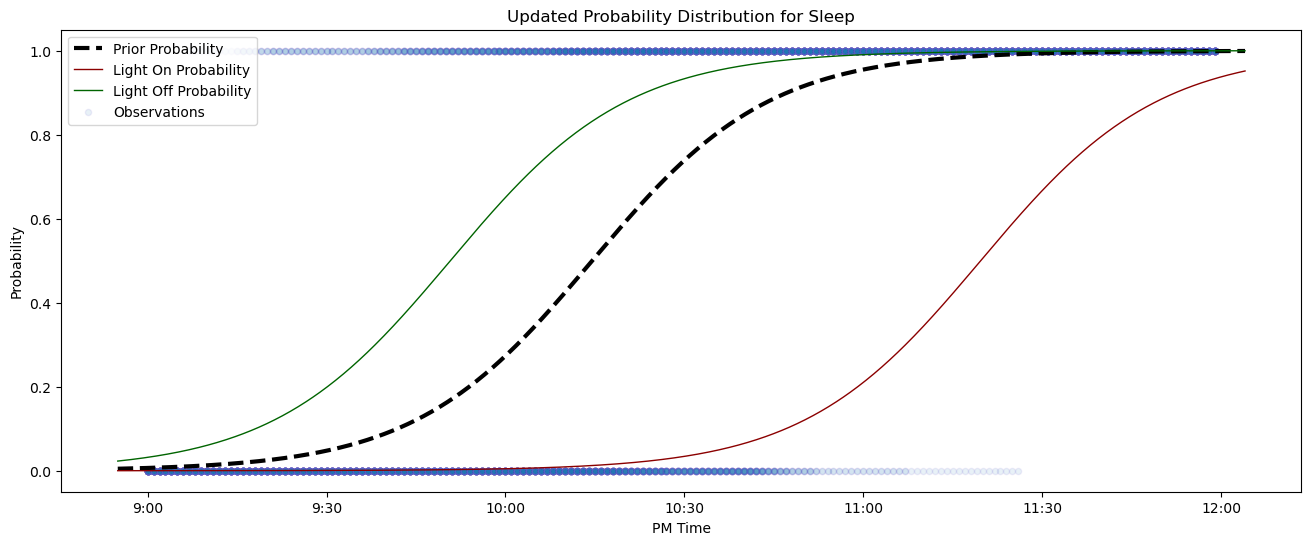

In [40]:
plt.plot(time_est, sleep_est, color = 'black', 
         lw=3, linestyle = '--', label="Prior Probability")
plt.plot(time_est, light_on_prob, color = 'darkred',
          lw = 1, label = 'Light On Probability')
plt.plot(time_est, light_off_prob, color = 'darkgreen',
           lw = 1, label = 'Light Off Probability')
plt.scatter(time, sleep_obs, edgecolor = 'slateblue',
            s=20, alpha=0.1, label='Observations')
plt.title('Updated Probability Distribution for Sleep');
plt.legend(loc=2)
plt.ylabel('Probability')
plt.xlabel('PM Time');
plt.xticks([-60, -30, 0, 30, 60, 90, 120], sleep_labels);